# Music Industry Sales Analysis: A 40-Year Story

**Audience:** Non-technical executives

**Objective:** Explore trends in music sales across formats from 1973 to 2019 and tell a story about how the industry has changed.

**Dataset:** 40 Years of Music Industry Sales (Format, Year, Value in millions)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
music_data = pd.read_csv('MusicData.csv')
music_data.head()

,?Format,Metric,Year,Number of Records,Value (Actual)
0,CD,Units,1973,1,NaN
1,CD,Units,1974,1,NaN
2,CD,Units,1975,1,NaN
3,CD,Units,1976,1,NaN
4,CD,Units,1977,1,NaN


In [3]:
music_data.rename(columns={'?Format': 'Format'}, inplace=True)

In [4]:
music_data['Metric'].unique()

array(['Units', 'Value', 'Value (Adjusted)'], dtype=object)

In [5]:
music_data['Format'].unique()

array(['CD', 'CD Single', 'Cassette', 'Cassette Single', 'LP/EP',
       'Vinyl Single', '8 - Track', 'Other Tapes',
       'Music Video (Physical)', 'DVD Audio', 'SACD', 'Download Single',
       'Download Album', 'Kiosk', 'Download Music Video',
       'Ringtones & Ringbacks', 'Paid Subscriptions',
       'Limited Tier Paid Subscription',
       'On-Demand Streaming (Ad-Supported)',
       'Other Ad-Supported Streaming', 'Other Digital',
       'Paid Subscription', 'SoundExchange Distributions',
       'Synchronization'], dtype=object)

In [6]:
music_data.dtypes

Format               object
Metric               object
Year                  int64
Number of Records     int64
Value (Actual)       object
dtype: object

In [7]:
music_data['Format'] = music_data['Format'].astype('str')

In [8]:
music_data['Value (Actual)'] = music_data['Value (Actual)'].str.replace(',', '').astype(float)

## Dataset Overview
We want to see which formats exist and how the sales are distributed over the years.

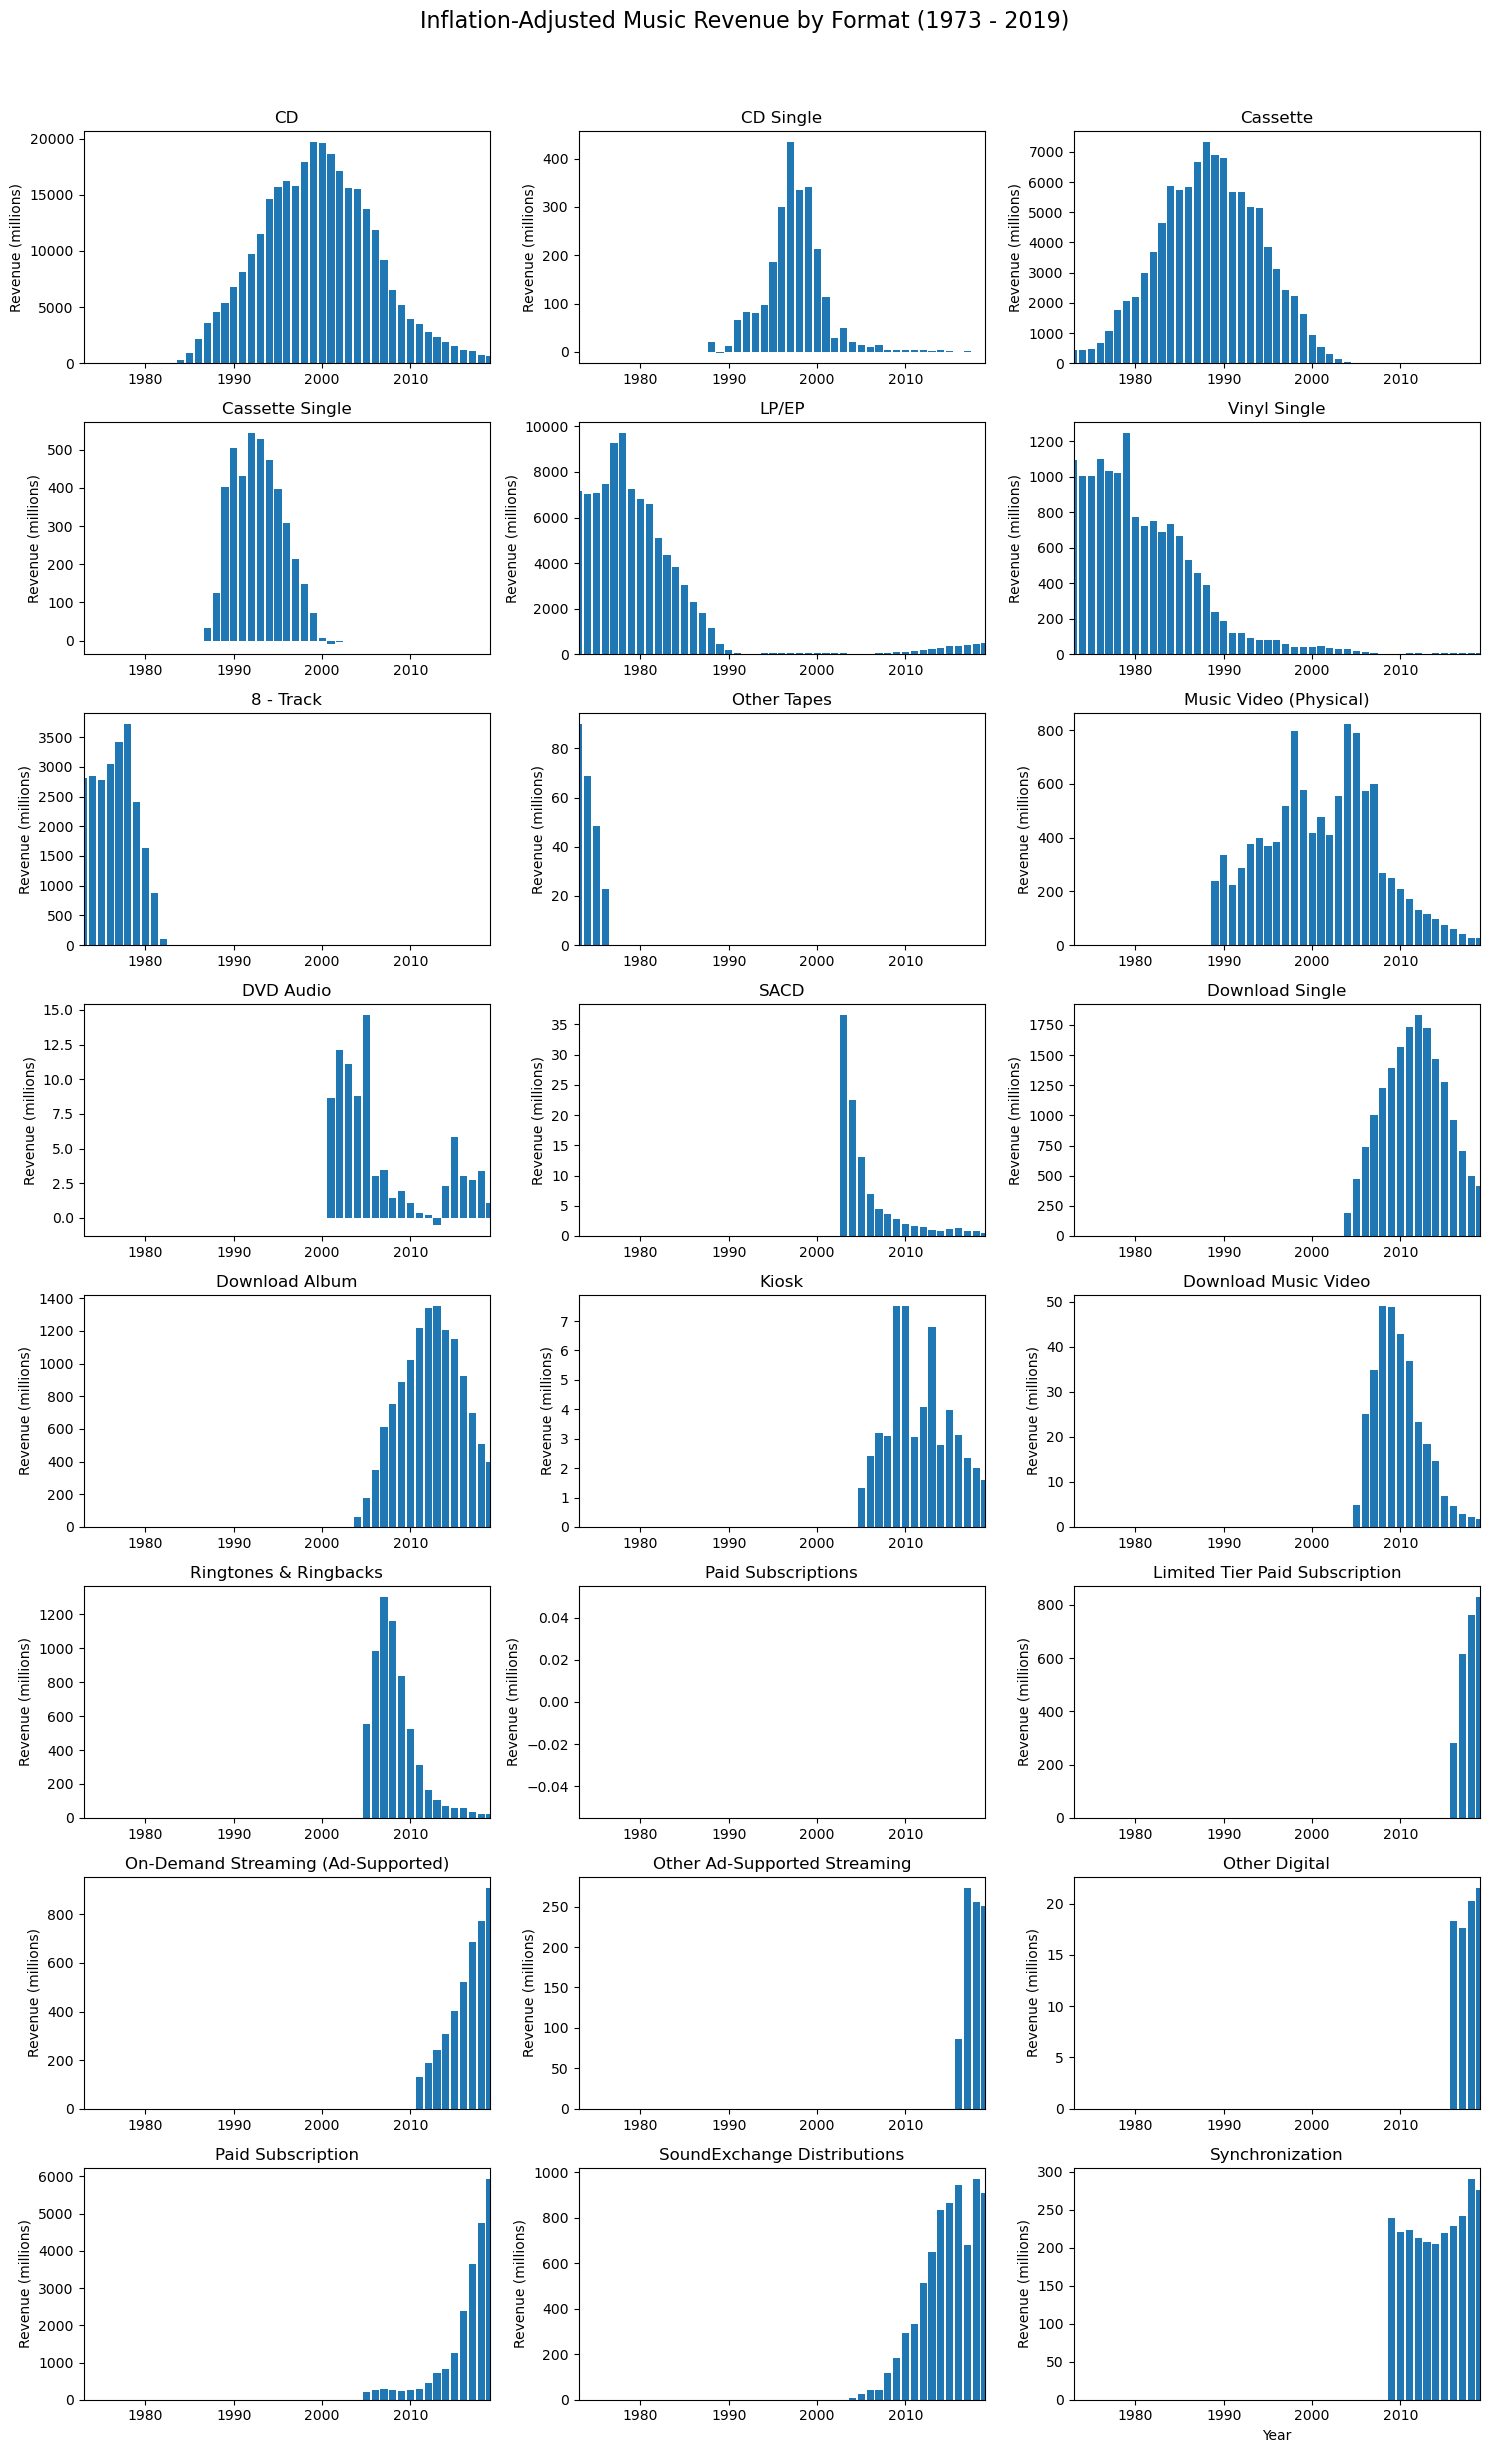

In [10]:
formats = music_data['Format'].unique()
min_year, max_year = music_data['Year'].min(), music_data['Year'].max()

adjusted_data = music_data[music_data['Metric'] == 'Value (Adjusted)']

n_cols = 3
n_rows = (len(formats) + n_cols - 1) // n_cols  
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*3))
axes = axes.flatten()

for ax, f in zip(axes, formats):
    df = adjusted_data[adjusted_data['Format'] == f]
    ax.bar(df['Year'], df['Value (Actual)']) 
    ax.set_title(f)
    ax.set_ylabel('Revenue (millions)')
    ax.set_xlim(min_year, max_year)

for ax in axes[len(formats):]:
    ax.axis('off')

fig.suptitle('Inflation-Adjusted Music Revenue by Format (1973 - 2019)', fontsize=16, y=1.02)
plt.xlabel('Year')
plt.tight_layout()
plt.show()

## Which formats generated the most revenue overall?

/var/folders/r0/mxnnbvln7wl__9w60hwgw01c0000gn/T/ipykernel_42036/159397012.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sales.index, y=top_sales.values, palette="viridis")


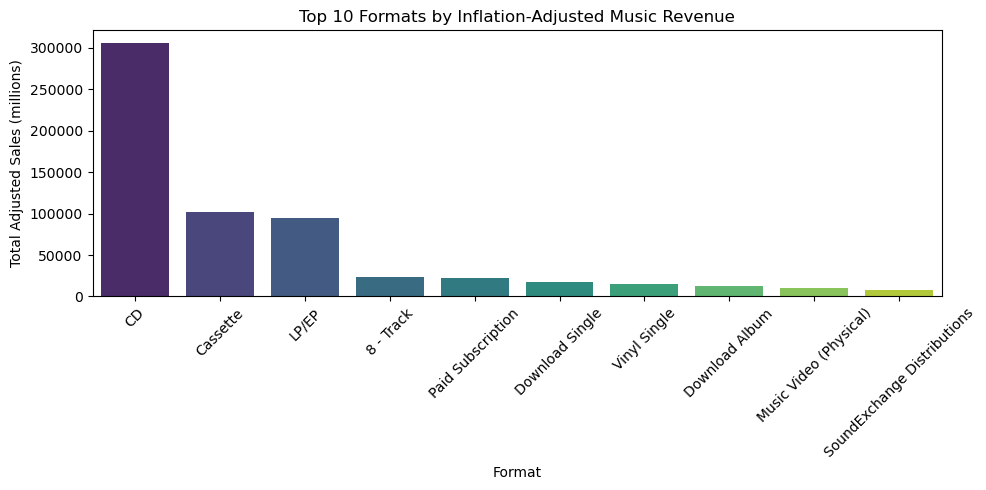

In [11]:
# Filter to inflation-adjusted revenue only
adjusted_data = music_data[music_data['Metric'] == 'Value (Adjusted)']

# Compute total adjusted revenue by format and get top 10
top_sales = (
    adjusted_data.groupby('Format')['Value (Actual)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_sales.index, y=top_sales.values, palette="viridis")
plt.ylabel('Total Adjusted Sales (millions)')
plt.title('Top 10 Formats by Inflation-Adjusted Music Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Choose the metric to analyze
metric_to_use = 'Value (Adjusted)'  # change to 'Units' or 'Value' if desired
filtered_data = music_data[music_data['Metric'] == metric_to_use]

print('\nBasic statistics for Inflation-Adjusted Revenue by Format from 1973-2019:\n')

# Group by Format and calculate stats
stats = filtered_data.groupby('Format')['Value (Actual)'].agg(
    Count='count',
    Total='sum',
    Mean='mean',
    Min='min',
    Max='max',
    Std='std'
).sort_values(by='Total', ascending=False)

print(stats)


Basic statistics for Inflation-Adjusted Revenue by Format from 1973-2019:

                                    Count          Total         Mean  \
Format                                                                  
CD                                     37  305524.451086  8257.417597   
Cassette                               36  102312.105824  2842.002940   
LP/EP                                  47   94233.655807  2004.971400   
8 - Track                              10   23640.469715  2364.046971   
Paid Subscription                      15   21731.722104  1448.781474   
Download Single                        16   17199.061065  1074.941317   
Vinyl Single                           47   14629.378953   311.263382   
Download Album                         16   12658.615697   791.163481   
Music Video (Physical)                 31   10619.480336   342.563882   
SoundExchange Distributions            16    7413.514033   463.344627   
Ringtones & Ringbacks                  15    621

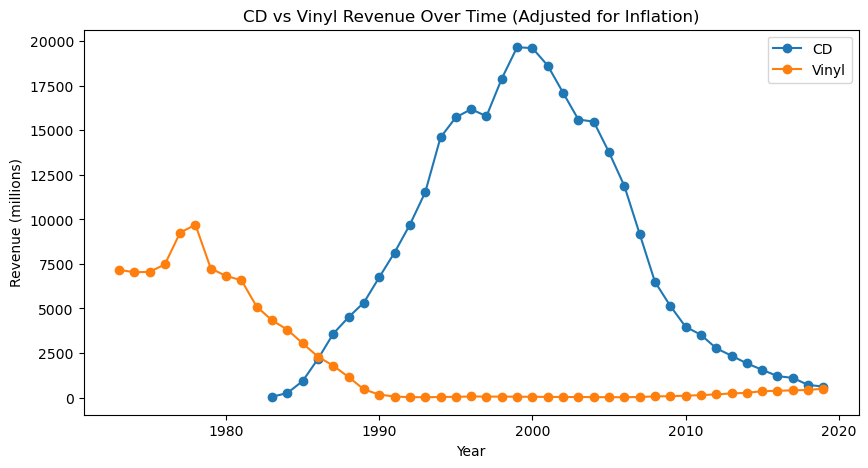

In [14]:
cd = music_data[
    (music_data['Format'] == 'CD') &
    (music_data['Metric'] == 'Value (Adjusted)')
]

vinyl = music_data[
    (music_data['Format'] == 'LP/EP') &
    (music_data['Metric'] == 'Value (Adjusted)')
]

plt.figure(figsize=(10,5))

plt.plot(cd['Year'], cd['Value (Actual)'], marker='o', label='CD')
plt.plot(vinyl['Year'], vinyl['Value (Actual)'], marker='o', label='Vinyl')

plt.xlabel('Year')
plt.ylabel('Revenue (millions)')
plt.title('CD vs Vinyl Revenue Over Time (Adjusted for Inflation)')
plt.legend()
plt.show()

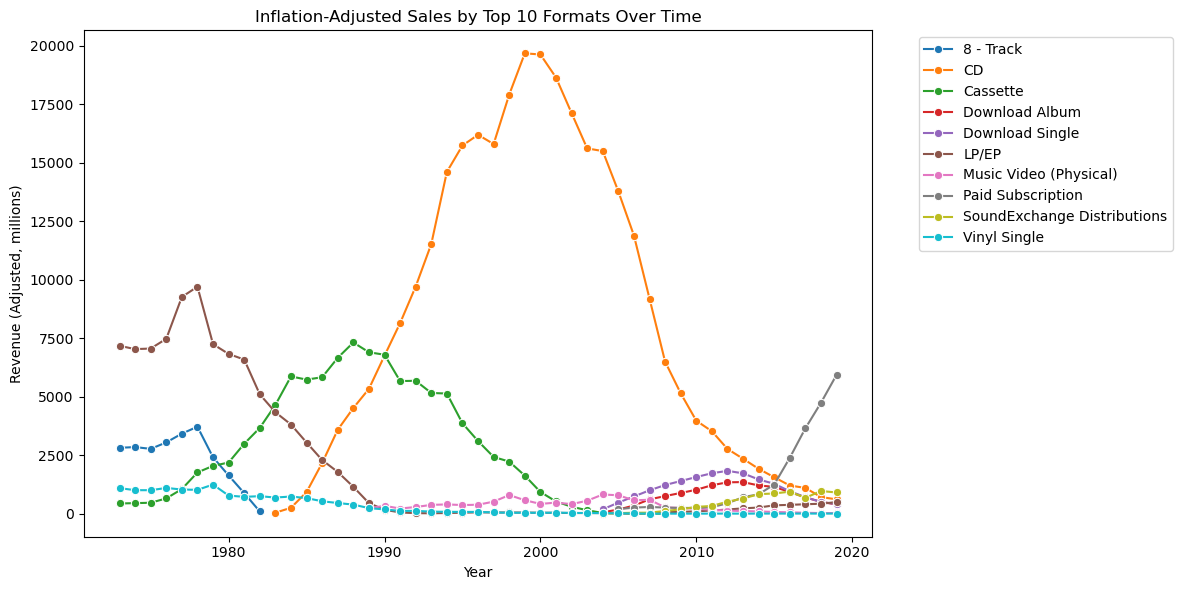

In [16]:
adjusted_data = music_data[music_data['Metric'] == 'Value (Adjusted)']

top_formats = (
    adjusted_data.groupby('Format')['Value (Actual)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

adjusted_top = adjusted_data[adjusted_data['Format'].isin(top_formats)]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=adjusted_top,
    x='Year',
    y='Value (Actual)',
    hue='Format',
    marker='o',
    palette='tab10'
)

plt.title('Inflation-Adjusted Sales by Top 10 Formats Over Time')
plt.ylabel('Revenue (Adjusted, millions)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/r0/mxnnbvln7wl__9w60hwgw01c0000gn/T/ipykernel_42036/2364403549.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_sales.values, y=avg_sales.index, palette='coolwarm')


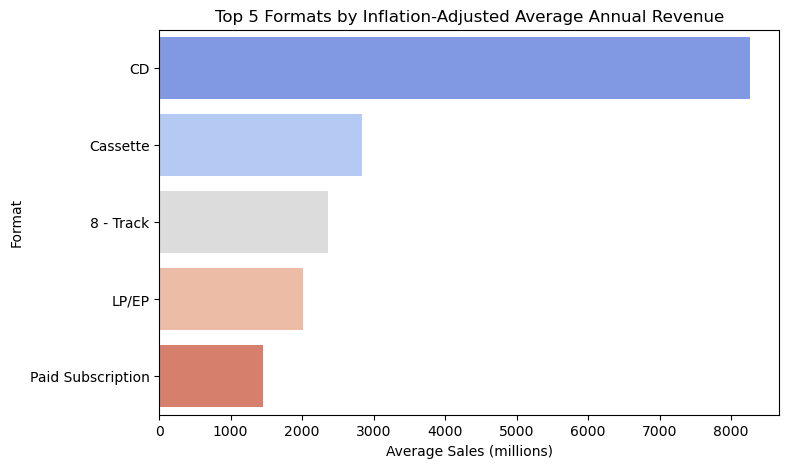

In [19]:
value_data = music_data[music_data['Metric'] == 'Value (Adjusted)']

avg_sales = value_data.groupby('Format')['Value (Actual)'].mean().sort_values(ascending=False).head(5)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=avg_sales.values, y=avg_sales.index, palette='coolwarm')
plt.title('Top 5 Formats by Inflation-Adjusted Average Annual Revenue')
plt.xlabel('Average Sales (millions)')
plt.ylabel('Format')
plt.show()

## Storytelling Summary:

- The music industry has shifted formats multiple times in 40 years.
- CDs peaked around 2000 and then declined with the rise of digital media.
- Vinyl dominated early on, before being replaced by casettes then CDs. Starting around 2010, it has been experiencing a small resurgence due to collectors.
- Streaming/digital formats are now the primary growth area.
- Executives can use these insights to forecast format trends and plan product strategies.